In [52]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [53]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int32)

# нормализация
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
def make_ordinal_labels(y):
    return y // 2   # 0-1->0, 2-3->1, 4-5->2, 6-7->3, 8-9->4

y_train_ord = make_ordinal_labels(y_train)
y_test_ord  = make_ordinal_labels(y_test)

# one-hot
def to_one_hot(y, num_classes):
    onehot = np.zeros((len(y), num_classes))
    onehot[np.arange(len(y)), y] = 1
    return onehot

num_classes = 5
y_train_onehot = to_one_hot(y_train_ord, num_classes)
y_test_onehot  = to_one_hot(y_test_ord, num_classes)

In [55]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [56]:
def loss_function(y_pred, y_true, mode="ce", alpha=2.0):
    B, C = y_pred.shape

    if mode == "ce":
        loss = -np.sum(y_true * np.log(y_pred + 1e-10)) / B
        dz = (y_pred - y_true) / B
        return loss, dz

    elif mode == "cdw":
        targets = np.argmax(y_true, axis=1)

        class_idx = np.arange(C)
        class_idx = np.tile(class_idx, (B,1))
        targets_exp = np.tile(targets.reshape(-1,1), (1,C))

        distances = np.abs(class_idx - targets_exp)
        weights = distances ** alpha

        loss_matrix = -np.log(1 - y_pred + 1e-10) * weights
        loss = np.mean(np.sum(loss_matrix, axis=1))

        g = weights / (1 - y_pred + 1e-10)
        dot = np.sum(y_pred * g, axis=1, keepdims=True)
        dz = y_pred * (g - dot)
        dz /= B

        return loss, dz

In [57]:
def accuracy(y_pred, y_true):
    return np.mean(
        np.argmax(y_pred, axis=1) ==
        np.argmax(y_true, axis=1)
    )

def mean_absolute_class_error(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    return np.mean(np.abs(pred_labels - true_labels))

In [58]:
def train_model(mode="ce", alpha=2.0, epochs=50, lr=0.05, batch_size=256):
    
    rng = np.random.default_rng(42)
    W = np.random.randn(784, num_classes) * 0.01
    b = np.zeros((1, num_classes))
    n = X_train.shape[0]
    num_batches = int(np.ceil(n / batch_size))

    for epoch in range(epochs):
        perm = rng.permutation(n)

        epoch_loss = 0.0

        for bi in range(num_batches):
            start = bi * batch_size
            end = min((bi + 1) * batch_size, n)
            idx = perm[start:end]

            Xb = X_train[idx]           
            Yb = y_train_onehot[idx]    

            # forward
            z = Xb @ W + b             
            y_pred = softmax(z)         

            # loss + gradient w.r.t logits
            loss, dz = loss_function(
                y_pred,
                Yb,
                mode=mode,
                alpha=alpha
            )

            epoch_loss += loss

            # backward
            dW = Xb.T @ dz               
            db = np.sum(dz, axis=0, keepdims=True) 

            # update
            W -= lr * dW
            b -= lr * db

        if (epoch + 1) % 10 == 0:
            z_full = X_train @ W + b
            y_full = softmax(z_full)

            train_acc = accuracy(y_full, y_train_onehot)
            train_mae = mean_absolute_class_error(y_full, y_train_onehot)

            print(f"Epoch {epoch+1}")
            print(f"Avg Loss: {epoch_loss / num_batches:.4f}, "
                  f"Acc: {train_acc:.4f}, "
                  f"MAE: {train_mae:.4f}")
            print()

    # тест
    z_test = np.dot(X_test, W) + b
    y_test_pred = softmax(z_test)

    test_acc = accuracy(y_test_pred, y_test_onehot)
    test_mae = mean_absolute_class_error(y_test_pred, y_test_onehot)

    print("FINAL TEST")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test MAE: {test_mae:.4f}")

    return W, b

In [59]:
print("CE")
W_ce, b_ce = train_model(mode="ce", epochs=50, lr=0.1, batch_size=256)

print("\nCDW alpha=0.25")
W_cdw1, b_cdw1 = train_model(mode="cdw", alpha=0.25, epochs=50, lr=0.05, batch_size=256)

print("\nCDW alpha=0.5")
W_cdw2, b_cdw2 = train_model(mode="cdw", alpha=0.5, epochs=50, lr=0.05, batch_size=256)

print("\nCDW alpha=0.75")
W_cdw3, b_cdw3 = train_model(mode="cdw", alpha=0.75, epochs=50, lr=0.05, batch_size=256)

print("\nCDW alpha=1.0")
W_cdw4, b_cdw4 = train_model(mode="cdw", alpha=1.0, epochs=50, lr=0.05, batch_size=256) 

print("\nCDW alpha=1.5")
W_cdw5, b_cdw5 = train_model(mode="cdw", alpha=1.5, epochs=50, lr=0.05, batch_size=256)

CE
Epoch 10
Avg Loss: 0.3727, Acc: 0.8901, MAE: 0.2183

Epoch 20
Avg Loss: 0.3692, Acc: 0.8903, MAE: 0.2167

Epoch 30
Avg Loss: 0.3669, Acc: 0.8912, MAE: 0.2143

Epoch 40
Avg Loss: 0.3661, Acc: 0.8916, MAE: 0.2158

Epoch 50
Avg Loss: 0.3663, Acc: 0.8924, MAE: 0.2127

FINAL TEST
Test Accuracy: 0.8819
Test MAE: 0.2323

CDW alpha=0.25
Epoch 10
Avg Loss: 0.2996, Acc: 0.8905, MAE: 0.2144

Epoch 20
Avg Loss: 0.2917, Acc: 0.8937, MAE: 0.2059

Epoch 30
Avg Loss: 0.2878, Acc: 0.8946, MAE: 0.2032

Epoch 40
Avg Loss: 0.2855, Acc: 0.8962, MAE: 0.2022

Epoch 50
Avg Loss: 0.2837, Acc: 0.8972, MAE: 0.1994

FINAL TEST
Test Accuracy: 0.8856
Test MAE: 0.2258

CDW alpha=0.5
Epoch 10
Avg Loss: 0.3486, Acc: 0.8900, MAE: 0.2090

Epoch 20
Avg Loss: 0.3397, Acc: 0.8924, MAE: 0.2025

Epoch 30
Avg Loss: 0.3352, Acc: 0.8933, MAE: 0.1998

Epoch 40
Avg Loss: 0.3327, Acc: 0.8950, MAE: 0.1977

Epoch 50
Avg Loss: 0.3307, Acc: 0.8955, MAE: 0.1971

FINAL TEST
Test Accuracy: 0.8839
Test MAE: 0.2221

CDW alpha=0.75
Epoch

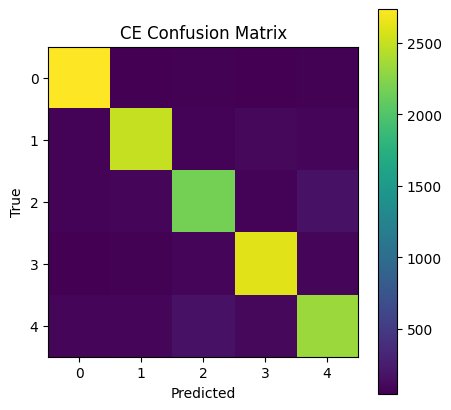

CE stats: (np.float64(0.2322857142857143), np.float64(0.029285714285714286))


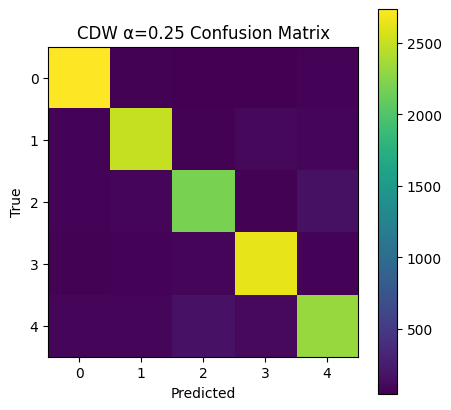

CDW α=0.25 stats: (np.float64(0.22578571428571428), np.float64(0.029))


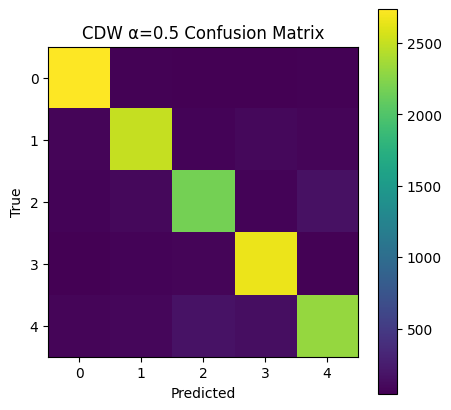

CDW α=0.5 stats: (np.float64(0.22214285714285714), np.float64(0.02692857142857143))


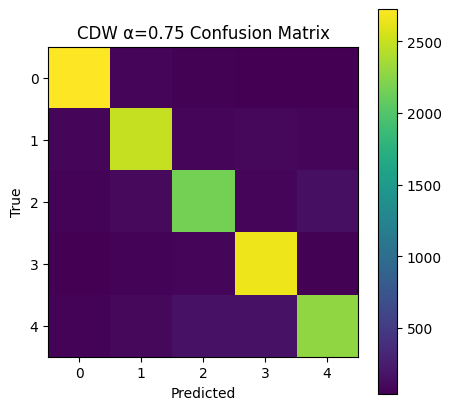

CDW α=0.75 stats: (np.float64(0.22278571428571428), np.float64(0.025714285714285714))


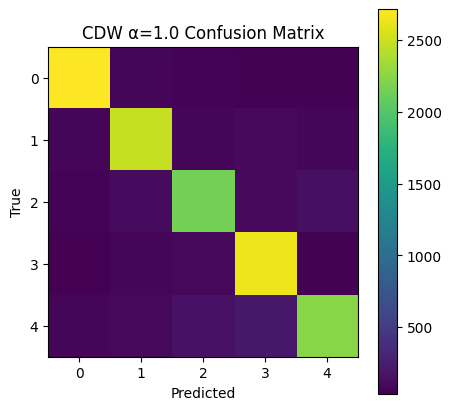

CDW α=1.0 stats: (np.float64(0.22614285714285715), np.float64(0.024714285714285713))


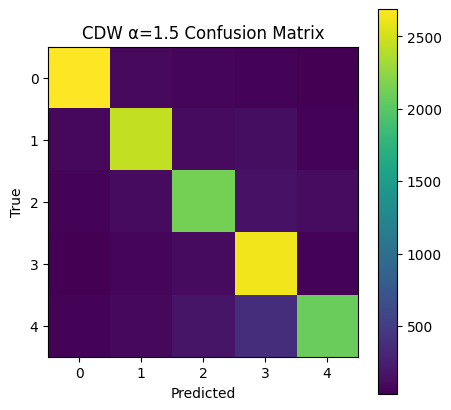

CDW α=1.5 stats: (np.float64(0.2387857142857143), np.float64(0.02207142857142857))


In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def get_confusion_matrix(W, b, X, y_true_onehot):
    z = X @ W + b
    y_pred = softmax(z)

    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    cm = confusion_matrix(y_true, y_pred_labels)
    return cm, y_true, y_pred_labels

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(5))
    plt.yticks(range(5))
    plt.show()

def distance_error_stats(y_true, y_pred):
    dist = np.abs(y_true - y_pred)
    
    mean_dist = np.mean(dist)

    # доля дальних ошибок (>=3)
    far_error_ratio = np.mean(dist >= 3)

    return mean_dist, far_error_ratio

# CE
cm_ce, y_true_ce, y_pred_ce = get_confusion_matrix(W_ce, b_ce, X_test, y_test_onehot)
plot_confusion_matrix(cm_ce, "CE Confusion Matrix")

stats_ce = distance_error_stats(y_true_ce, y_pred_ce)
print("CE stats:", stats_ce)

# CDW alpha=0.25
cm_cdw1, y_true_cdw1, y_pred_cdw1 = get_confusion_matrix(W_cdw1, b_cdw1, X_test, y_test_onehot)
plot_confusion_matrix(cm_cdw1, "CDW α=0.25 Confusion Matrix")
stats_cdw1 = distance_error_stats(y_true_cdw1, y_pred_cdw1)
print("CDW α=0.25 stats:", stats_cdw1)

# CDW alpha=0.5
cm_cdw2, y_true_cdw2, y_pred_cdw2 = get_confusion_matrix(W_cdw2, b_cdw2, X_test, y_test_onehot)
plot_confusion_matrix(cm_cdw2, "CDW α=0.5 Confusion Matrix")
stats_cdw2 = distance_error_stats(y_true_cdw2, y_pred_cdw2)
print("CDW α=0.5 stats:", stats_cdw2)

# CDW alpha=0.75
cm_cdw3, y_true_cdw3, y_pred_cdw3 = get_confusion_matrix(W_cdw3, b_cdw3, X_test, y_test_onehot)
plot_confusion_matrix(cm_cdw3, "CDW α=0.75 Confusion Matrix")
stats_cdw3 = distance_error_stats(y_true_cdw3, y_pred_cdw3)
print("CDW α=0.75 stats:", stats_cdw3)

# CDW alpha=1.0
cm_cdw4, y_true_cdw4, y_pred_cdw4 = get_confusion_matrix(W_cdw4, b_cdw4, X_test, y_test_onehot)
plot_confusion_matrix(cm_cdw4, "CDW α=1.0 Confusion Matrix")
stats_cdw4 = distance_error_stats(y_true_cdw4, y_pred_cdw4)
print("CDW α=1.0 stats:", stats_cdw4)

# CDW alpha=1.5
cm_cdw5, y_true_cdw5, y_pred_cdw5 = get_confusion_matrix(W_cdw5, b_cdw5, X_test, y_test_onehot)
plot_confusion_matrix(cm_cdw5, "CDW α=1.5 Confusion Matrix")
stats_cdw5 = distance_error_stats(y_true_cdw5, y_pred_cdw5)
print("CDW α=1.5 stats:", stats_cdw5)

Epoch 10
Avg Loss: 0.3000, Acc: 0.8920, MAE: 0.2109

Epoch 20
Avg Loss: 0.2932, Acc: 0.8941, MAE: 0.2046

Epoch 30
Avg Loss: 0.2908, Acc: 0.8947, MAE: 0.2019

Epoch 40
Avg Loss: 0.2889, Acc: 0.8962, MAE: 0.2015

Epoch 50
Avg Loss: 0.2871, Acc: 0.8966, MAE: 0.2012

FINAL TEST
Test Accuracy: 0.8842
Test MAE: 0.2263
Epoch 10
Avg Loss: 0.3511, Acc: 0.8908, MAE: 0.2076

Epoch 20
Avg Loss: 0.3438, Acc: 0.8917, MAE: 0.2027

Epoch 30
Avg Loss: 0.3403, Acc: 0.8931, MAE: 0.1982

Epoch 40
Avg Loss: 0.3388, Acc: 0.8954, MAE: 0.1968

Epoch 50
Avg Loss: 0.3368, Acc: 0.8950, MAE: 0.1980

FINAL TEST
Test Accuracy: 0.8819
Test MAE: 0.2254
Epoch 10
Avg Loss: 0.4148, Acc: 0.8882, MAE: 0.2059

Epoch 20
Avg Loss: 0.4053, Acc: 0.8883, MAE: 0.2023

Epoch 30
Avg Loss: 0.4019, Acc: 0.8895, MAE: 0.1977

Epoch 40
Avg Loss: 0.4004, Acc: 0.8920, MAE: 0.1955

Epoch 50
Avg Loss: 0.3980, Acc: 0.8912, MAE: 0.1986

FINAL TEST
Test Accuracy: 0.8770
Test MAE: 0.2273
Epoch 10
Avg Loss: 0.4915, Acc: 0.8829, MAE: 0.2082

Ep

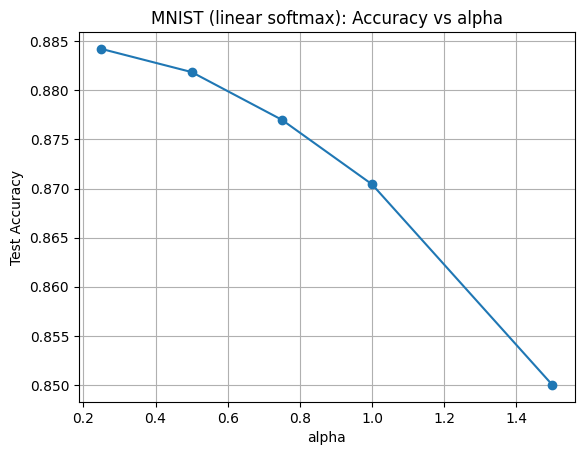

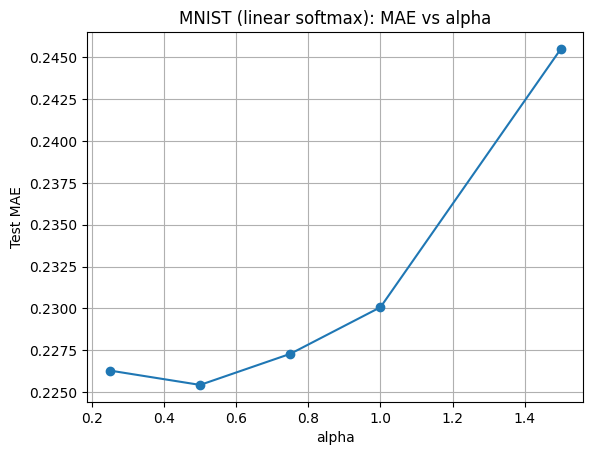

Best Accuracy: 0.8842 at alpha=0.25
Best MAE:      0.2254 at alpha=0.5


In [61]:
def evaluate_model(W, b, X, y_onehot):
    z = X @ W + b
    y_pred = softmax(z)
    acc = accuracy(y_pred, y_onehot)
    mae = mean_absolute_class_error(y_pred, y_onehot)
    return acc, mae

def run_alpha_sweep(alphas, lr=0.1, epochs=50, batch_size=256, verbose=False):
    results = {"alpha": [], "acc": [], "mae": []}

    for a in alphas:
        W, b = train_model(mode="cdw", alpha=float(a), epochs=epochs, lr=lr, batch_size=batch_size)

        z_test = X_test @ W + b
        y_test_pred = softmax(z_test)
        acc = accuracy(y_test_pred, y_test_onehot)
        mae = mean_absolute_class_error(y_test_pred, y_test_onehot)

        results["alpha"].append(float(a))
        results["acc"].append(float(acc))
        results["mae"].append(float(mae))

        if verbose:
            print(f"alpha={a}: acc={acc:.4f}, mae={mae:.4f}")

    return results

def plot_alpha_curves(results, title_prefix="CDW-CE"):
    alphas = np.array(results["alpha"], dtype=float)
    acc = np.array(results["acc"], dtype=float)
    mae = np.array(results["mae"], dtype=float)

    order = np.argsort(alphas)
    alphas, acc, mae = alphas[order], acc[order], mae[order]

    # Accuracy vs alpha
    plt.figure()
    plt.plot(alphas, acc, marker="o")
    plt.xlabel("alpha")
    plt.ylabel("Test Accuracy")
    plt.title(f"{title_prefix}: Accuracy vs alpha")
    plt.grid(True)
    plt.show()

    # MAE vs alpha
    plt.figure()
    plt.plot(alphas, mae, marker="o")
    plt.xlabel("alpha")
    plt.ylabel("Test MAE")
    plt.title(f"{title_prefix}: MAE vs alpha")
    plt.grid(True)
    plt.show()

    best_acc_i = int(np.argmax(acc))
    best_mae_i = int(np.argmin(mae))
    print(f"Best Accuracy: {acc[best_acc_i]:.4f} at alpha={alphas[best_acc_i]}")
    print(f"Best MAE:      {mae[best_mae_i]:.4f} at alpha={alphas[best_mae_i]}")

alphas = [0.25, 0.5, 0.75, 1.0, 1.5]  
res = run_alpha_sweep(alphas, lr=0.1, epochs=50, batch_size=256, verbose=False)
plot_alpha_curves(res, title_prefix="MNIST (linear softmax)")